In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
#Create an X and Y array
x = np.arange(1, 90, 6)
y = np.array([20, 40, 50, 45, 65, 70, 90, 100, 99, 115, 120, 123, 115, 145, 139])

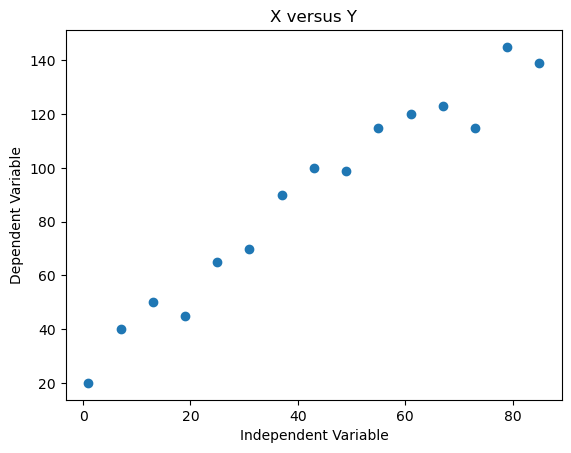

In [3]:
plt.scatter(x, y)
plt.title("X versus Y")
plt.ylabel("Dependent Variable")
plt.xlabel("Independent Variable")
plt.show()

In [18]:
# Find optimal values for slope and intercept in equation y = mx+b

def lin_reg_params(x, y, learningrate, epochs, slope = 0, intercept = 0):
    m = slope #initialize slope to 0
    b = intercept #initialize intercept to 0
    n = len(x) #How many observations

    for epoch in range(epochs):
        grad_m = 0.0 #Reset slope gradient to 0
        grad_b = 0.0 #Reset intercept gradient to 0
        for i in range(n): # Within the epoch, now pass each observation through. Could also use for obs in range(len(x))
            y_hat = m * x[i] + b #Pass each observation through the equation to get a predicted y value
            error_numer = y_hat - y[i] #Calculate the error term for how far prediction was from observed value

            grad_m += error_numer * x[i] #update the slope gradient with each observation error term multiplied by the observation (part of partial derivative for slope.)
            grad_b += error_numer #update the intercept gradient with each observation error term multiplied by the observation (part of partial derivative for intercept.)
        
        grad_m *= (2/n) #Scale the slope gradient total from the observations. Part of the partial derivative equation for slope.
        grad_b *= (2/n) #Scale the intercept gradient total from the observations. Part of the partial derivative equation for intercept.

        m -= learningrate * grad_m # Slope will now be updated with best value to use.
        b -= learningrate * grad_b # Intercept will now be updated with best value to use.
    m = round(m, 3)
    b = round(b, 3)
    return m, b
            


In [19]:
def linearregressionfinder(x, y, slope = 0, intercept = 0, learningrate = 0.0001, epochs = 1000):
    m, b = lin_reg_params(x, y, learningrate, epochs, slope, intercept)
    n = len(x)
    error = 0
    for i in range(n):
        y_hat = m*x[i] + b
        error_add = (y[i] - y_hat)**2
        error += error_add
    error = round((1/n) * error, 3)
    return error, m, b

mse, slope, intercept = linearregressionfinder(x,y)

print(f"Your mean squared error is: {mse}. Your slope is {slope} and your intercept is {intercept}.")


Your mean squared error is: 256.595. Your slope is 1.869 and your intercept is 1.513.


In [20]:
#Create some predictions for y based on the function
y_pred = (slope * x) + intercept

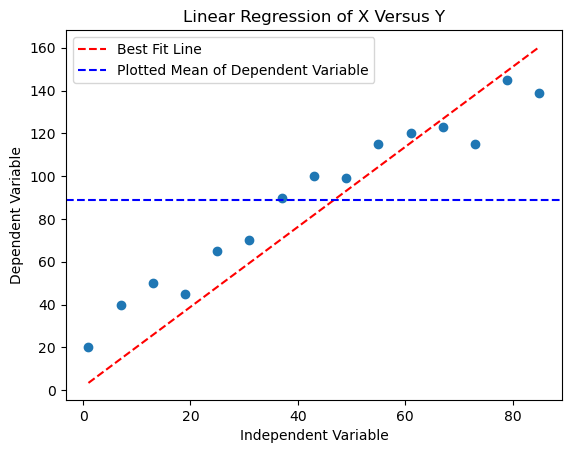

In [21]:
# Plot the predicted values as a regression line compared to actual values
plt.scatter(x,y)
plt.plot(x, y_pred, color = 'red', linestyle = '--', label = "Best Fit Line")
plt.axhline(np.mean(y), color = 'blue', linestyle = '--', label = "Plotted Mean of Dependent Variable")
plt.title("Linear Regression of X Versus Y")
plt.xlabel("Independent Variable")
plt.ylabel("Dependent Variable")
plt.legend()
plt.show()